## Gold Visualisations and EDA

This notebook loads saved Gold parquet outputs and generates two visual suites: exploratory analysis charts and model interpretation charts.

### Notebook Flow

1. Resolve project paths and validate required Gold inputs.
2. Load analytical and modelling output tables.
3. Generate EDA visuals for class balance, transaction behaviour, and merchant patterns.
4. Generate model interpretation visuals for performance and error analysis.
5. Save all visuals to the Gold visuals folder.

In [1]:
# =========================================================================
# Import libraries
# =========================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
# =========================================================================
# Resolve directories and create visuals output folder
# =========================================================================

current_dir = Path.cwd().resolve()
candidate_data_dirs = [
    current_dir / "Data",
    current_dir.parent / "Data",
]
data_dir = next((path for path in candidate_data_dirs if path.exists()), candidate_data_dirs[0])
if not data_dir.exists():
    checked = "\n - ".join(str(path) for path in candidate_data_dirs)
    raise FileNotFoundError(f"Data directory not found. Checked:\n - {checked}")

gold_dir = data_dir / "gold"
if not gold_dir.exists():
    raise FileNotFoundError(f"Gold directory not found: {gold_dir}")

visuals_dir = gold_dir / "visuals"
visuals_dir.mkdir(parents=True, exist_ok=True)

print("Current working directory:", current_dir)
print("Data directory:", data_dir)
print("Gold directory:", gold_dir)
print("Visuals directory:", visuals_dir)

Current working directory: C:\Users\9370892\OneDrive - Lloyds Banking Group\Apprenticeship - Data Science\Data Science Pro Practice\Assessment\Scripts
Data directory: C:\Users\9370892\OneDrive - Lloyds Banking Group\Apprenticeship - Data Science\Data Science Pro Practice\Assessment\Data
Gold directory: C:\Users\9370892\OneDrive - Lloyds Banking Group\Apprenticeship - Data Science\Data Science Pro Practice\Assessment\Data\gold
Visuals directory: C:\Users\9370892\OneDrive - Lloyds Banking Group\Apprenticeship - Data Science\Data Science Pro Practice\Assessment\Data\gold\visuals


In [3]:
# =========================================================================
# Load Gold parquet outputs and report their dimensions
# =========================================================================

required_gold_files = {
    "metrics": gold_dir / "gold_model_metrics.parquet",
    "confusion_matrix": gold_dir / "gold_confusion_matrix.parquet",
    "feature_importance": gold_dir / "gold_feature_importance.parquet",
    "scored_transactions": gold_dir / "gold_scored_transactions.parquet",
    "fraud_distribution": gold_dir / "gold_fraud_distribution.parquet",
    "risk_band_summary": gold_dir / "gold_risk_band_summary.parquet",
}

missing_required_files = [
    str(path)
    for path in required_gold_files.values()
    if not path.exists()
]
if missing_required_files:
    missing_text = "\n - ".join(missing_required_files)
    raise FileNotFoundError(
        f"Required Gold files are missing:\n - {missing_text}"
    )

metrics_viz = pd.read_parquet(required_gold_files["metrics"])
confusion_matrix_viz = pd.read_parquet(required_gold_files["confusion_matrix"])
feature_importance_viz = pd.read_parquet(required_gold_files["feature_importance"])
scored_transactions_viz = pd.read_parquet(required_gold_files["scored_transactions"])
fraud_distribution_viz = pd.read_parquet(required_gold_files["fraud_distribution"])
risk_band_summary_viz = pd.read_parquet(required_gold_files["risk_band_summary"])

optional_merchant_path = gold_dir / "gold_merchant_category_summary.parquet"
if optional_merchant_path.exists():
    merchant_category_summary_viz = pd.read_parquet(optional_merchant_path)
else:
    merchant_category_summary_viz = pd.DataFrame()

loaded_frames = {
    "metrics": metrics_viz,
    "confusion_matrix": confusion_matrix_viz,
    "feature_importance": feature_importance_viz,
    "scored_transactions": scored_transactions_viz,
    "fraud_distribution": fraud_distribution_viz,
    "risk_band_summary": risk_band_summary_viz,
    "merchant_category_summary": merchant_category_summary_viz,
}

print("Gold outputs loaded successfully.")
for name, dataframe in loaded_frames.items():
    print(f" - {name:24} | shape={dataframe.shape}")

Gold outputs loaded successfully.
 - metrics                  | shape=(6, 2)
 - confusion_matrix         | shape=(2, 2)
 - feature_importance       | shape=(176, 2)
 - scored_transactions      | shape=(1782993, 71)
 - fraud_distribution       | shape=(2, 3)
 - risk_band_summary        | shape=(3, 2)
 - merchant_category_summary | shape=(108, 4)


## Exploratory Data Analysis (EDA) Visuals

The following visuals focus on metrics such as fraud distribution, transaction values, risk bands and merchant-category patterns.

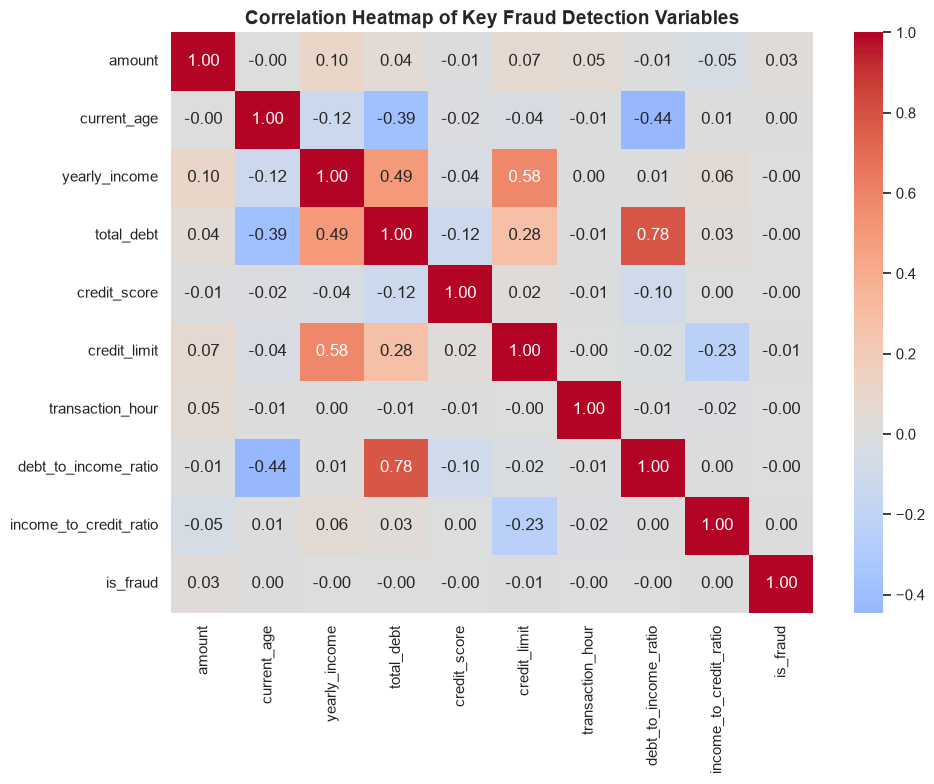

In [4]:
# =========================================================================
# EDA - Correlation heatmap
# =========================================================================

heatmap_features = [
    "amount",
    "current_age",
    "yearly_income",
    "total_debt",
    "credit_score",
    "credit_limit",
    "transaction_hour",
    "debt_to_income_ratio",
    "income_to_credit_ratio",
    "is_fraud",
]

available_heatmap_features = [
    column
    for column in heatmap_features
    if column in scored_transactions_viz.columns
]
if len(available_heatmap_features) < 2:
    raise ValueError(
        "Not enough numeric features available to build a correlation heatmap."
    )

heatmap_df = scored_transactions_viz[available_heatmap_features].copy()
corr_matrix = heatmap_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)
plt.title(
    "Correlation Heatmap of Key Fraud Detection Variables",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(
    visuals_dir / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()
plt.close()

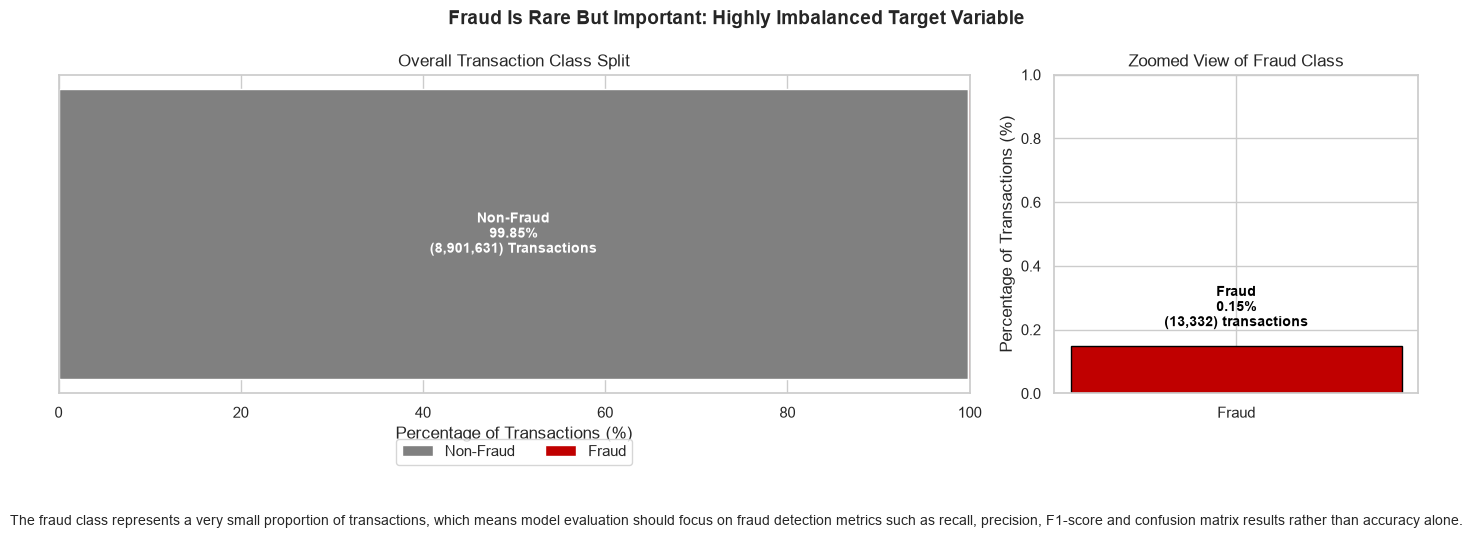

In [181]:
# =========================================================================
# EDA - Visualize fraud vs non-fraud imbalance with zoomed fraud view
# =========================================================================

fraud_pct_df = fraud_distribution_viz.copy()

fraud_pct_df["pct_display"] = (
    fraud_pct_df["transaction_count"] /
    fraud_pct_df["transaction_count"].sum()
) * 100

fraud_pct_df["label"] = fraud_pct_df["is_fraud"].map(
    {0: "Non-Fraud", 1: "Fraud"}
).fillna(fraud_pct_df["is_fraud"].astype(str))

# Sort so Non-Fraud appears first, Fraud second
fraud_pct_df = fraud_pct_df.sort_values("is_fraud")

colours = {
    "Non-Fraud": "#808080",
    "Fraud": "#C00000"
}

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [2.5, 1]}
)

# -------------------------------------------------------------------------
# Left visual: full percentage split
# -------------------------------------------------------------------------

ax = axes[0]

left = 0

for _, row in fraud_pct_df.iterrows():
    pct = row["pct_display"]
    lbl = row["label"]
    count = row["transaction_count"]

    ax.barh(
        y=0,
        width=pct,
        left=left,
        color=colours.get(lbl, "#333333"),
        edgecolor="white",
        height=0.5,
        label=lbl
    )

    # Label large segments inside the bar
    count = row["transaction_count"]
    
    if lbl == "Non-Fraud":

        ax.text(
            left + pct / 2,
            0,
            f"{lbl}\n{pct:.2f}%\n({count:,.0f}) Transactions",
            va="center",
            ha="center",
            fontsize=10,
            color="white",
            fontweight="bold"
    )

    left += pct

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Percentage of Transactions (%)")
ax.set_title("Overall Transaction Class Split")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.25), ncol=2)

# -------------------------------------------------------------------------
# Right visual: zoomed fraud percentage
# -------------------------------------------------------------------------

fraud_row = fraud_pct_df[fraud_pct_df["label"] == "Fraud"].iloc[0]
fraud_pct = fraud_row["pct_display"]
fraud_count = fraud_row["transaction_count"]

ax2 = axes[1]

ax2.bar(
    x=["Fraud"],
    height=[fraud_pct],
    color="#C00000",
    edgecolor="black"
)
if fraud_pct > 5:

    ax2.text(
        0,
        fraud_pct,
        f"Fraud\n{fraud_pct:.2f}%\n({fraud_count:,.0f}) Transactions",
        va="center",
        ha="center",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

else:

    ax2.text(
        0,
        fraud_pct + 0.12,
        f"Fraud\n{fraud_pct:.2f}%\n({fraud_count:,.0f}) transactions",
        va="center",
        ha="center",
        fontsize=10,
        color="black",
        fontweight="bold"
    )

ax2.set_ylim(0, max(fraud_pct * 1.6, 1))
ax2.set_ylabel("Percentage of Transactions (%)")
ax2.set_title("Zoomed View of Fraud Class")

# -------------------------------------------------------------------------
# Overall title and annotation
# -------------------------------------------------------------------------

fig.suptitle(
    "Fraud Is Rare But Important: Highly Imbalanced Target Variable",
    fontsize=14,
    fontweight="bold"
)

fig.text(
    0.5,
    -0.05,
    "The fraud class represents a very small proportion of transactions, "
    "which means model evaluation should focus on fraud detection metrics "
    "such as recall, precision, F1-score and confusion matrix results rather than accuracy alone.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig(
    visuals_dir / "fraud_percentage_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

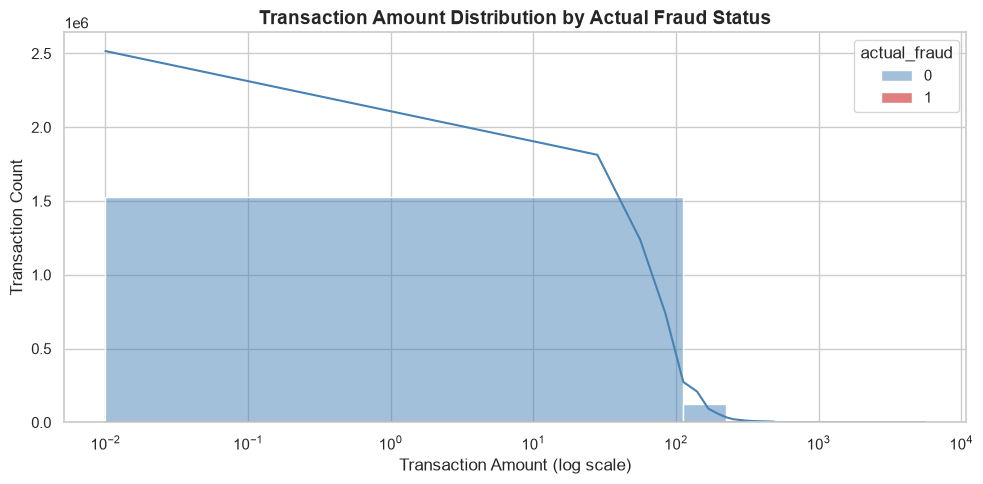

In [ ]:
# =========================================================================
# EDA - Transaction amount distribution by actual fraud status
# =========================================================================

required_cols = {"amount", "actual_fraud"}
if required_cols.issubset(scored_transactions_viz.columns):
    amount_sample = scored_transactions_viz[["amount", "actual_fraud"]].dropna().copy()
    amount_sample = amount_sample[amount_sample["amount"] > 0]

    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=amount_sample,
        x="amount",
        hue="actual_fraud",
        bins=50,
        kde=True,
        palette={0: "#4682B4", 1: "#C00000"},
    )
    plt.xscale("log")
    plt.title(
        "Transaction Amount Distribution by Actual Fraud Status",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Transaction Amount (log scale)")
    plt.ylabel("Transaction Count")
    plt.tight_layout()
    plt.savefig(
        visuals_dir / "transaction_amount_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()
else:
    print("Required columns missing for this chart: amount, actual_fraud")

C:\Users\9370892\AppData\Local\Temp\ipykernel_27164\2432850793.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


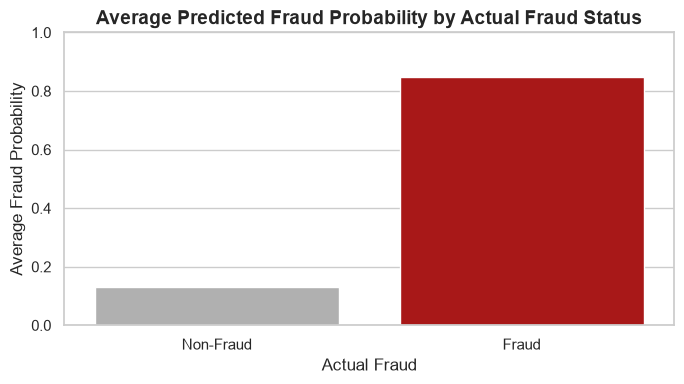

In [ ]:
# =========================================================================
# EDA - Average predicted fraud probability by actual fraud status
# =========================================================================

if {"actual_fraud", "fraud_probability"}.issubset(scored_transactions_viz.columns):
    avg_probability_df = (
        scored_transactions_viz
        .groupby("actual_fraud", as_index=False)["fraud_probability"]
        .mean()
    )

    plt.figure(figsize=(7, 4))
    sns.barplot(
        data=avg_probability_df,
        x="actual_fraud",
        y="fraud_probability",
        palette=["#B0B0B0", "#C00000"],
    )
    plt.title(
        "Average Predicted Fraud Probability by Actual Fraud Status",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Actual Fraud")
    plt.ylabel("Average Fraud Probability")
    plt.xticks(ticks=[0, 1], labels=["Non-Fraud", "Fraud"])
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(
        visuals_dir / "average_fraud_probability.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()
else:
    print("actual_fraud and fraud_probability columns are required for this visual.")

C:\Users\9370892\AppData\Local\Temp\ipykernel_27164\2662960300.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


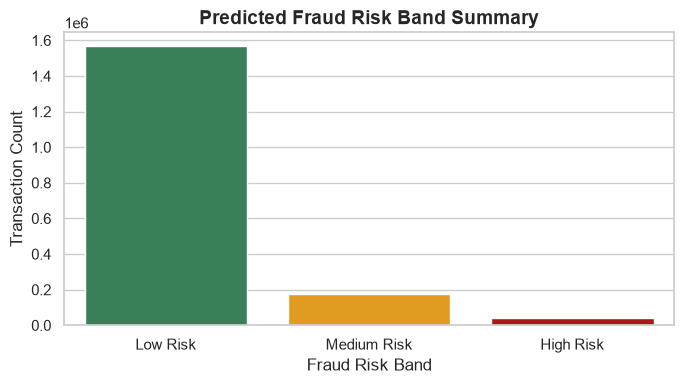

In [172]:
# =========================================================================
# EDA - Visualize the predicted fraud risk band summary
# =========================================================================

risk_order = ["Low Risk", "Medium Risk", "High Risk"]

risk_palette = {
    "Low Risk": "#2E8B57",
    "Medium Risk": "#FFA500",
    "High Risk": "#C00000"
}

risk_band_summary_viz["fraud_risk_band"] = pd.Categorical(
    risk_band_summary_viz["fraud_risk_band"],
    categories=risk_order,
    ordered=True
)

risk_band_summary_viz = risk_band_summary_viz.sort_values("fraud_risk_band")

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=risk_band_summary_viz,
    x="fraud_risk_band",
    y="transaction_count",
    order=risk_order,
    palette=[risk_palette[risk] for risk in risk_order]
)

plt.title(
    "Predicted Fraud Risk Band Summary",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Fraud Risk Band")
plt.ylabel("Transaction Count")

plt.tight_layout()

plt.savefig(
    visuals_dir / "fraud_risk_band_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

C:\Users\9370892\AppData\Local\Temp\ipykernel_27164\466116867.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


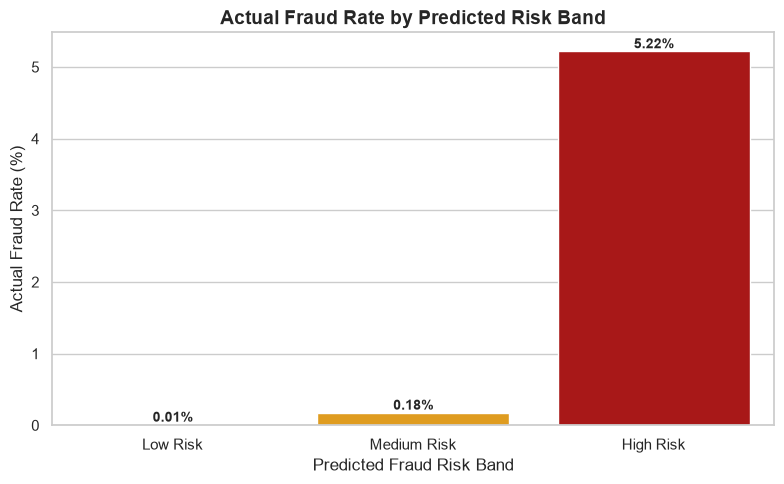

In [173]:
# =========================================================================
# EDA - Visualize actual fraud rate by predicted fraud risk band
# =========================================================================

if {"fraud_risk_band", "actual_fraud"}.issubset(
    scored_transactions_viz.columns
):

    # Calculate fraud and non-fraud counts by risk band
    risk_summary = (
        scored_transactions_viz
        .groupby(
            ["fraud_risk_band", "actual_fraud"],
            observed=False
        )
        .size()
        .unstack(fill_value=0)
    )

    # Ensure both columns exist
    if 0 not in risk_summary.columns:
        risk_summary[0] = 0

    if 1 not in risk_summary.columns:
        risk_summary[1] = 0

    # Calculate fraud rate
    risk_summary["fraud_rate_pct"] = (
        risk_summary[1]
        / (risk_summary[0] + risk_summary[1])
    ) * 100

    # Reset index for plotting
    risk_summary = risk_summary.reset_index()

    # Order categories
    risk_order = [
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]

    risk_summary["fraud_risk_band"] = pd.Categorical(
        risk_summary["fraud_risk_band"],
        categories=risk_order,
        ordered=True
    )

    risk_summary = risk_summary.sort_values(
        "fraud_risk_band"
    )

    # Plot
    plt.figure(figsize=(8, 5))

    colours = [
        "#2E8B57",  # Low Risk
        "#FFA500",  # Medium Risk
        "#C00000"   # High Risk
    ]

    ax = sns.barplot(
        data=risk_summary,
        x="fraud_risk_band",
        y="fraud_rate_pct",
        palette=colours
    )

    # Add labels
    for container in ax.containers:

        for bar in container:

            height = bar.get_height()

            ax.annotate(
                f"{height:.2f}%",
                (
                    bar.get_x()
                    + bar.get_width() / 2,
                    height
                ),
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

    plt.title(
        "Actual Fraud Rate by Predicted Risk Band",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Predicted Fraud Risk Band")
    plt.ylabel("Actual Fraud Rate (%)")
    plt.tight_layout()
    plt.savefig(
        visuals_dir / "actual_fraud_rate_by_risk_band.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

else:
    print(
        "fraud_risk_band and actual_fraud columns are required for this visual."
    )

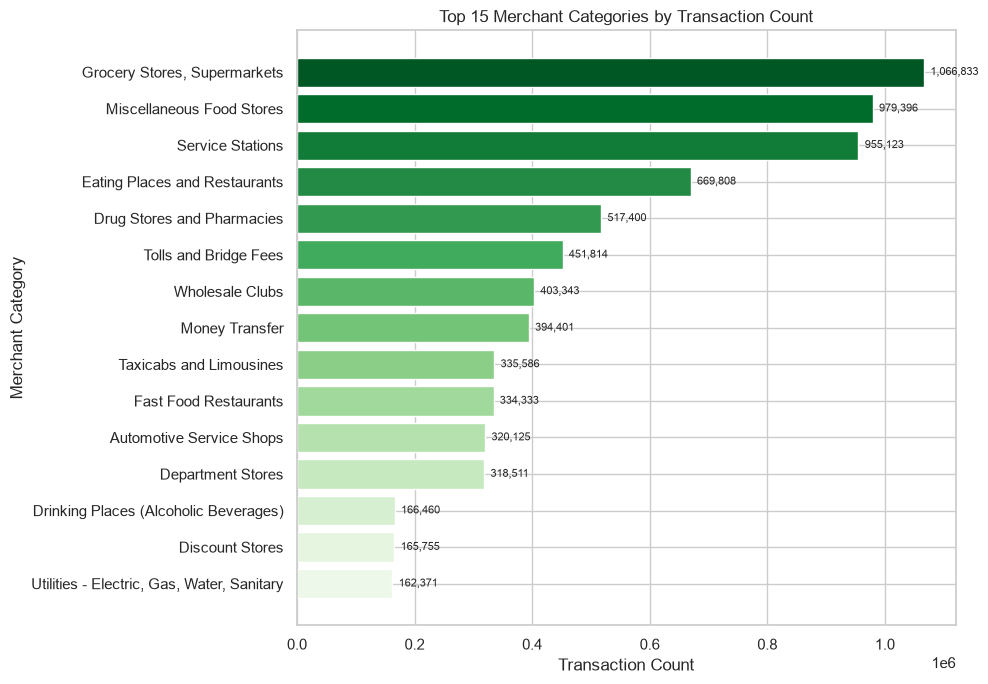

In [5]:
# =========================================================================
# EDA - Top merchant categories by transaction count
# =========================================================================

required_cols = {"merchant_category", "transaction_count"}
if (
    not merchant_category_summary_viz.empty
    and required_cols.issubset(merchant_category_summary_viz.columns)
):
    top_categories_count = (
        merchant_category_summary_viz
        .sort_values("transaction_count", ascending=False)
        .head(15)
        .sort_values("transaction_count", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    colours = sns.color_palette("Greens", n_colors=len(top_categories_count))

    bars = ax.barh(
        top_categories_count["merchant_category"],
        top_categories_count["transaction_count"],
        color=colours,
    )

    xmax = max(bar.get_width() for bar in bars)
    for bar in bars:
        ax.text(
            bar.get_width() + xmax * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}",
            ha="left",
            va="center",
            fontsize=8,
        )

    ax.set_title("Top 15 Merchant Categories by Transaction Count")
    ax.set_xlabel("Transaction Count")
    ax.set_ylabel("Merchant Category")
    plt.tight_layout()
    plt.savefig(
        visuals_dir / "top_merchant_categories.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()
else:
    print(
        "Merchant category summary file is unavailable or missing required columns."
    )

C:\Users\9370892\AppData\Local\Temp\ipykernel_27164\3428602778.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


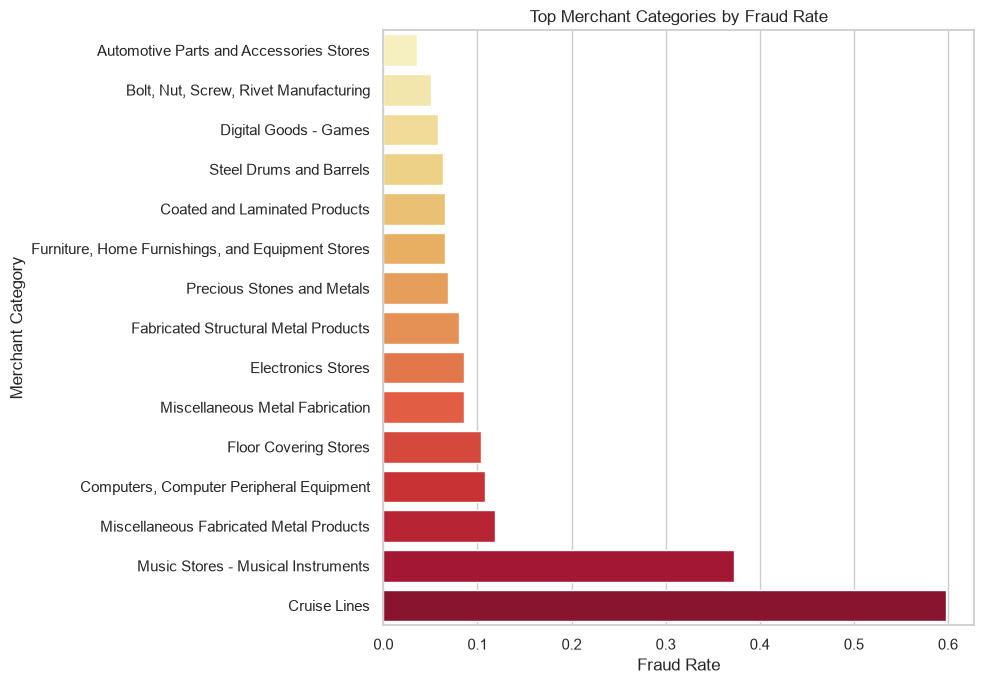

In [175]:
# =========================================================================
# EDA - Visualize the top merchant categories by fraud rate
# =========================================================================

if not merchant_category_summary_viz.empty and {
    "merchant_category", "fraud_rate"}.issubset(
        merchant_category_summary_viz.columns):
    top_categories_fraud_rate = (
        merchant_category_summary_viz
        .sort_values("fraud_rate", ascending=False)
        .head(15)
    )

    plt.figure(figsize = (10, 7))
    top_categories_fraud_rate = (
    top_categories_fraud_rate
    .sort_values("fraud_rate", ascending=True)
    )

    colours = sns.color_palette(
        "YlOrRd",
        n_colors=len(top_categories_fraud_rate)
    )

    sns.barplot(
        data=top_categories_fraud_rate,
        x="fraud_rate",
        y="merchant_category",
        palette=colours
    )
    plt.title("Top Merchant Categories by Fraud Rate")
    plt.xlabel("Fraud Rate")
    plt.ylabel("Merchant Category")
    plt.tight_layout()
    plt.savefig(
        visuals_dir / "top_merchant_categories_by_fraud_rate.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

else:
    print("Merchant category summary file is not available or does not contain the required columns.")

## Model Interpretation Visuals

The following visuals focus on model performance and interpretation.


C:\Users\9370892\AppData\Local\Temp\ipykernel_27164\173114783.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


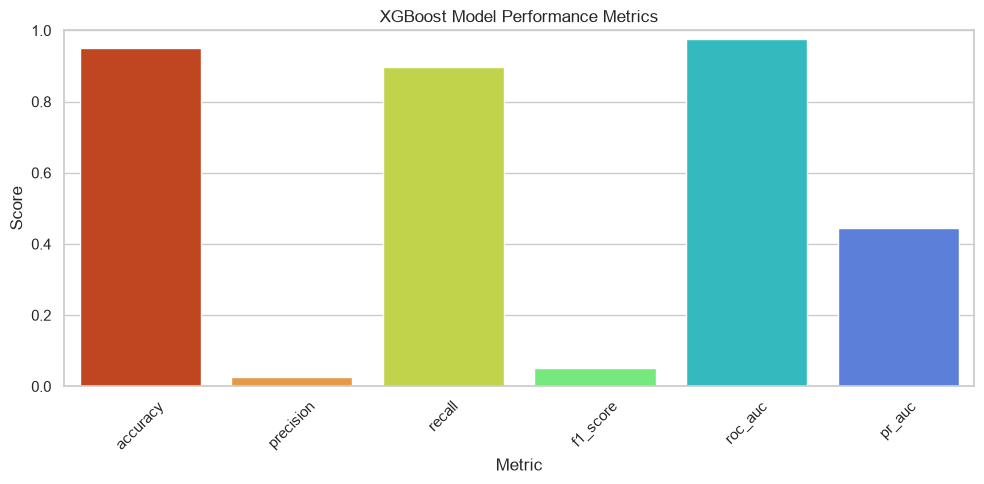

In [176]:
# =========================================================================
# Visualize the XGBoost model performance metrics
# =========================================================================

plt.figure(figsize = (10, 5))

colours = sns.color_palette(
    "turbo_r",
    n_colors=len(metrics_viz)
)

sns.barplot(
    data=metrics_viz,
    x="metric",
    y="value",
    palette=colours
)

plt.title("XGBoost Model Performance Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    visuals_dir / "xgboost_model_performance_metrics.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()
plt.close()

In [ ]:
print("Confusion matrix shape:", confusion_matrix_viz.shape)
print("Confusion matrix columns:", confusion_matrix_viz.columns.tolist())

<class 'pandas.DataFrame'>


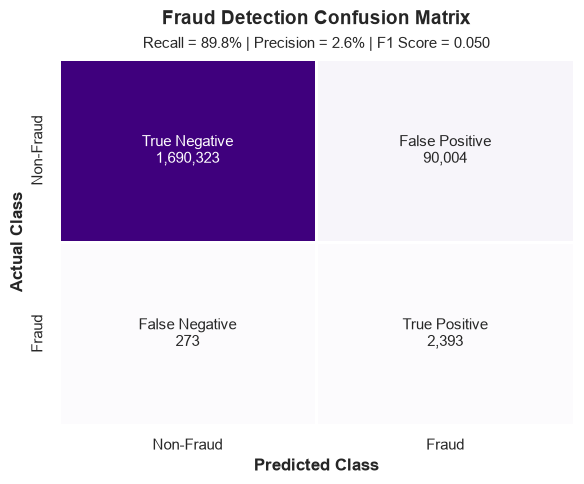

In [178]:
# =========================================================================
# Enhanced Confusion Matrix Visualisation
# =========================================================================

# Extract values from confusion matrix

tn, fp, fn, tp = confusion_matrix_viz.values.ravel()

# Calculate evaluation metrics
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * ((precision * recall) / (precision + recall))
false_positive_rate = fp / (fp + tn)

# Create labels for heatmap
labels = np.array([
    [
        f"True Negative\n{tn:,}",
        f"False Positive\n{fp:,}"
    ],
    [
        f"False Negative\n{fn:,}",
        f"True Positive\n{tp:,}"
    ]
])

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_viz,
    annot=labels,
    fmt="",
    cmap="Purples",
    linewidths=1,
    linecolor="white",
    cbar=False,
    annot_kws={"size": 11}
)

plt.title(
    "Fraud Detection Confusion Matrix",
    fontsize=14,
    fontweight="bold",
    pad=25
)

plt.text(
    0.5,
    1.03,
    f"Recall = {recall:.1%} | Precision = {precision:.1%} | F1 Score = {f1:.3f}",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=11
)

plt.xlabel("Predicted Class", 
    fontsize=12,
    fontweight="bold"
)
plt.ylabel("Actual Class", 
    fontsize=12,
    fontweight="bold")
plt.xticks(
    [0.5, 1.5],
    ["Non-Fraud", "Fraud"],
    fontsize=11
)

plt.yticks(
    [0.5, 1.5],
    ["Non-Fraud", "Fraud"],
    rotation=90,
    fontsize=11
)

plt.tight_layout()
plt.savefig(
    visuals_dir / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


C:\Users\9370892\AppData\Local\Temp\ipykernel_48576\53358362.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


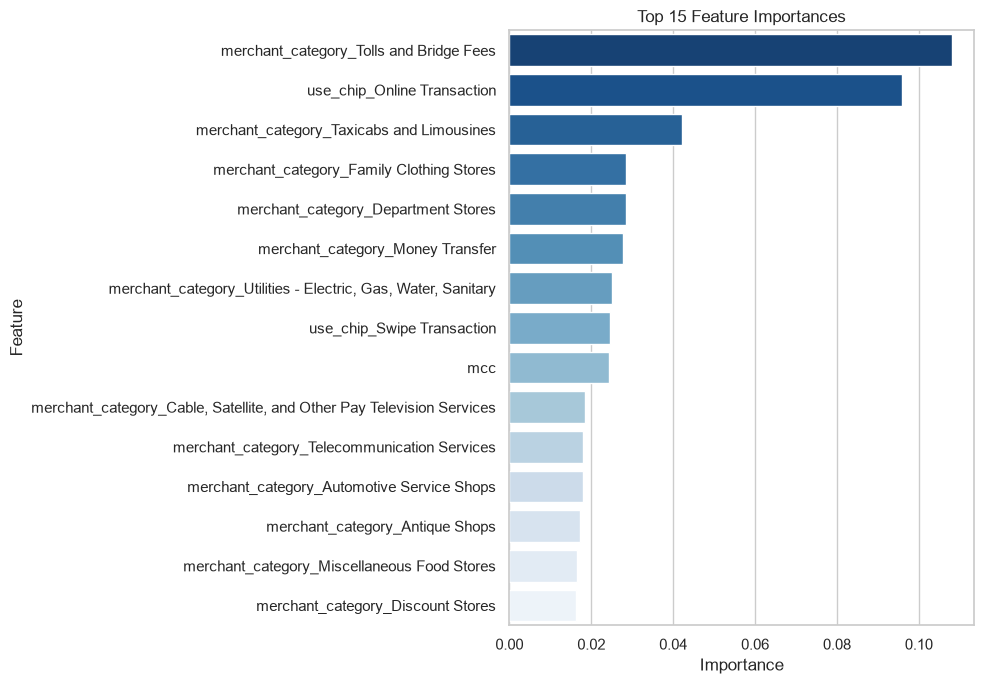

In [10]:
# =========================================================================
# Visualize the top 15 XGBoost feature importances
# =========================================================================

top_features = feature_importance_viz.head(15)

plt.figure(figsize=(10, 7))

top_features = top_features.sort_values("importance", ascending=False)

colours = sns.color_palette(
    "Blues_r",
    n_colors=len(top_features),
)

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette=colours,
 )

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    visuals_dir / "top_15_xgboost_feature_importances.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

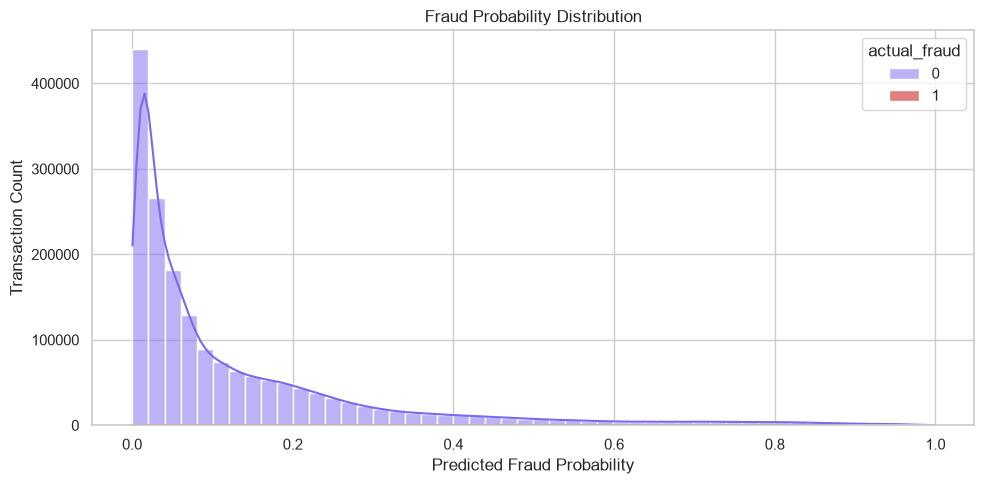

In [180]:
# =========================================================================
# Visualize Fraud Probability Distribution
# =========================================================================

plt.figure(figsize = (10, 5))

sns.histplot(
    data=scored_transactions_viz,
    x="fraud_probability",
    hue="actual_fraud",
    bins=50,
    kde=True,
    palette={
        0: "#7B68EE",
        1: "#C00000"
    }
)

plt.title("Fraud Probability Distribution")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.savefig(
    visuals_dir / "fraud_probability_distribution.png",
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()
plt.close()

## Visualisation Summary

Use this section to summarise the EDA visuals, including class imbalance, transaction amount behaviour, risk-band distribution, and merchant category patterns.

Use this section to summarise model interpretation visuals, including performance metrics, confusion-matrix errors, key predictors, and fraud-probability behaviour.